In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

In [2]:
df=pd.read_csv("netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [3]:
df.rename(columns={"listed_in":"genre"},inplace=True)
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [4]:
#dropping the show_id column as it may be of no use in the analysis
df.drop(columns="show_id",inplace=True)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.shape

(8807, 11)

In [7]:
df.isna().sum()

type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
genre              0
description        0
dtype: int64

In [8]:
#droppin the rows which have null values in date_added column as there are only 10 values which sums upto only 0.11%
df.dropna(subset=["date_added"],inplace=True)
df["date_added"].isna().sum()

np.int64(0)

In [9]:
#dropping the rows which have null values in rating column as there are only 4 values which sums upto only 0.05%
df.dropna(subset=["rating"],inplace=True)
df["rating"].isna().sum()

np.int64(0)

In [10]:
#dropping the rows which have null values in duration column as there are only 3 values which sums upto only 0.04%
df.dropna(subset=["duration"],inplace=True)
df["duration"].isna().sum()

np.int64(0)

In [11]:
df.isna().sum()

type               0
title              0
director        2621
cast             825
country          829
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
dtype: int64

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   type          8790 non-null   object
 1   title         8790 non-null   object
 2   director      6169 non-null   object
 3   cast          7965 non-null   object
 4   country       7961 non-null   object
 5   date_added    8790 non-null   object
 6   release_year  8790 non-null   int64 
 7   rating        8790 non-null   object
 8   duration      8790 non-null   object
 9   genre         8790 non-null   object
 10  description   8790 non-null   object
dtypes: int64(1), object(10)
memory usage: 824.1+ KB


In [13]:
# df["date_added"]=pd.to_datetime(df["date_added"])
# df["date_added"]

df["date_added"]=pd.to_datetime(df["date_added"],errors="coerce")
df["date_added"].isnull().sum()

np.int64(88)

In [14]:
df.dropna(subset=["date_added"],inplace=True)
df["date_added"].isna().sum()

np.int64(0)

In [15]:
#adding day,month,year,month_name,day_name as seprate columns to the dataframe as the these will help in creating new columns
df["day"]=df["date_added"].dt.day
df["month"]=df["date_added"].dt.month
df["year"]=df["date_added"].dt.year
df["month_name"]=df["date_added"].dt.month_name()
df["weekday"]=df["date_added"].dt.day_name()
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [16]:
df["rating"].unique()

array(['PG-13', 'TV-MA', 'PG', 'TV-14', 'TV-PG', 'TV-Y', 'TV-Y7', 'R',
       'TV-G', 'G', 'NC-17', 'NR', 'TV-Y7-FV', 'UR'], dtype=object)

In [17]:
# Netflix has officially categorised theese into 3 main categories (https://help.netflix.com/en/node/2064/us), so using that for our EDA
# Replacing 'TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV' to Kids,
# 'PG-13','TV-14' to Teens,
# 'R','TV-MA','NC-17' to Adults,
# and 'NR','UR' to null values

In [18]:
df['rating'] = df['rating'].replace(['TV-Y','TV-Y7','G','TV-G','PG','TV-PG','TV-Y7-FV'],'Kids')
df['rating'] = df['rating'].replace(['PG-13','TV-14'],'Teens')
df['rating'] = df['rating'].replace(['R','TV-MA','NC-17'],'Adults')
df['rating'] = df['rating'].replace(['NR','UR'],np.nan)
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
3,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,2021-09-24,2021,Adults,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo...",24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday


In [19]:
df["rating"].unique()

array(['Teens', 'Adults', 'Kids', nan], dtype=object)

In [20]:
df["rating"].isna().sum()

np.int64(81)

In [21]:
df.dropna(subset=["rating"],inplace=True)
df["rating"].isna().sum()

np.int64(0)

In [22]:
df.isna().sum()

type               0
title              0
director        2535
cast             800
country          826
date_added         0
release_year       0
rating             0
duration           0
genre              0
description        0
day                0
month              0
year               0
month_name         0
weekday            0
dtype: int64

In [23]:
# now we still have about 48% missing data so we will check in which rows the director,cast,country all three as null
# if all these 3 are null values then there is no use of that row
df[(df["director"].isna()) & (df["cast"].isna()) & (df["country"].isna())].shape[0]

96

In [24]:
df.shape

(8621, 16)

In [25]:
# how is for drop rows 
# all for where in 3 columns all 3 values are null
# 
df.dropna(subset=["director","cast","country"],how="all",inplace=True)
df.shape

(8525, 16)

In [26]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,Adults,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,9,2021,September,Friday


In [27]:
df_cast=pd.DataFrame(df["cast"].apply(lambda x:str(x).split(", ")).tolist(),index=df["title"])
df_cast

,0,1,2,3,4,5,6,7,8,9,...,40,41,42,43,44,45,46,47,48,49
title,,,,,,,,,,,,,,,,,,,,,
Dick Johnson Is Dead,nan,None,None,None,None,None,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Blood & Water,Ama Qamata,Khosi Ngema,Gail Mabalane,Thabang Molaba,Dillon Windvogel,Natasha Thahane,Arno Greeff,Xolile Tshabalala,Getmore Sithole,Cindy Mahlangu,...,None,None,None,None,None,None,None,None,None,None
Ganglands,Sami Bouajila,Tracy Gotoas,Samuel Jouy,Nabiha Akkari,Sofia Lesaffre,Salim Kechiouche,Noureddine Farihi,Geert Van Rampelberg,Bakary Diombera,None,...,None,None,None,None,None,None,None,None,None,None
Kota Factory,Mayur More,Jitendra Kumar,Ranjan Raj,Alam Khan,Ahsaas Channa,Revathi Pillai,Urvi Singh,Arun Kumar,None,None,...,None,None,None,None,None,None,None,None,None,None
Midnight Mass,Kate Siegel,Zach Gilford,Hamish Linklater,Henry Thomas,Kristin Lehman,Samantha Sloyan,Igby Rigney,Rahul Kohli,Annarah Cymone,Annabeth Gish,...,None,None,None,None,None,None,None,None,None,None
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Zinzana,Ali Suliman,Saleh Bakri,Yasa,Ali Al-Jabri,Mansoor Alfeeli,Ahd,None,None,None,None,...,None,None,None,None,None,None,None,None,None,None
Zodiac,Mark Ruffalo,Jake Gyllenhaal,Robert Downey Jr.,Anthony Edwards,Brian Cox,Elias Koteas,Donal Logue,John Carroll Lynch,Dermot Mulroney,Chloë Sevigny,...,None,None,None,None,None,None,None,None,None,None
Zombieland,Jesse Eisenberg,Woody Harrelson,Emma Stone,Abigail Breslin,Amber Heard,Bill Murray,Derek Graf,None,None,None,...,None,None,None,None,None,None,None,None,None,None


In [28]:
df_cast=df_cast.stack()
df_cast

title                  
Dick Johnson Is Dead  0                      nan
Blood & Water         0               Ama Qamata
                      1              Khosi Ngema
                      2            Gail Mabalane
                      3           Thabang Molaba
                                   ...          
Zubaan                3         Manish Chaudhary
                      4             Meghna Malik
                      5            Malkeet Rauni
                      6           Anita Shabdish
                      7    Chittaranjan Tripathy
Length: 63644, dtype: object

In [29]:
df_cast=pd.DataFrame(df_cast)
df_cast

0
title                                        
Dick Johnson Is Dead 0                    nan
Blood & Water        0             Ama Qamata
                     1            Khosi Ngema
                     2          Gail Mabalane
                     3         Thabang Molaba
...                                       ...
Zubaan               3       Manish Chaudhary
                     4           Meghna Malik
                     5          Malkeet Rauni
                     6         Anita Shabdish
                     7  Chittaranjan Tripathy

[63644 rows x 1 columns]

In [30]:
df_cast.reset_index(inplace=True)
df_cast

,title,level_1,0
0,Dick Johnson Is Dead,0,nan
1,Blood & Water,0,Ama Qamata
2,Blood & Water,1,Khosi Ngema
3,Blood & Water,2,Gail Mabalane
4,Blood & Water,3,Thabang Molaba
...,...,...,...
63639,Zubaan,3,Manish Chaudhary
63640,Zubaan,4,Meghna Malik
63641,Zubaan,5,Malkeet Rauni
63642,Zubaan,6,Anita Shabdish


In [31]:
df_cast=df_cast[["title",0]]
df_cast

,title,0
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [32]:
df_cast.columns=["title","cast"]
df_cast

,title,cast
0,Dick Johnson Is Dead,nan
1,Blood & Water,Ama Qamata
2,Blood & Water,Khosi Ngema
3,Blood & Water,Gail Mabalane
4,Blood & Water,Thabang Molaba
...,...,...
63639,Zubaan,Manish Chaudhary
63640,Zubaan,Meghna Malik
63641,Zubaan,Malkeet Rauni
63642,Zubaan,Anita Shabdish


In [33]:
df_cast.replace("nan",np.nan,inplace=True)
df_cast.isna().sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\356088169.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_cast.replace("nan",np.nan,inplace=True)


title      0
cast     704
dtype: int64

In [34]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,Adults,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,9,2021,September,Friday


In [35]:
df_genre=pd.DataFrame(df["genre"].apply(lambda x:str(x).split(", ")).tolist(),index=df["title"])
df_genre=df_genre.stack()
df_genre=pd.DataFrame(df_genre)
df_genre.reset_index(inplace=True)
df_genre=df_genre[["title",0]]
df_genre.columns=["title","genre"]
df_genre.replace("nan",np.nan,inplace=True)
df_genre.isna().sum()

title    0
genre    0
dtype: int64

In [36]:
df_director=pd.DataFrame(df["director"].apply(lambda x:str(x).split(", ")).tolist(),index=df["title"])
df_director=df_director.stack()
df_director=pd.DataFrame(df_director)
df_director.reset_index(inplace=True)
df_director=df_director[["title",0]]
df_director.columns=["title","director"]
df_director.replace("nan",np.nan,inplace=True)
df_director.isna().sum()

title          0
director    2439
dtype: int64

In [37]:
df_country=pd.DataFrame(df["country"].apply(lambda x:str(x).split(", ")).tolist(),index=df["title"])
df_country=df_country.stack()
df_country=pd.DataFrame(df_country)
df_country.reset_index(inplace=True)
df_country=df_country[["title",0]]
df_country.columns=["title","country"]
df_country.replace("nan",np.nan,inplace=True)
df_country.isna().sum()

title        0
country    730
dtype: int64

In [38]:
df.columns

Index(['type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'genre', 'description', 'day',
       'month', 'year', 'month_name', 'weekday'],
      dtype='object')

In [39]:
df.head()

,type,title,director,cast,country,date_added,release_year,rating,duration,genre,description,day,month,year,month_name,weekday
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday
2,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,2021-09-24,2021,Adults,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...,24,9,2021,September,Friday
4,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...,24,9,2021,September,Friday
5,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,2021-09-24,2021,Adults,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...,24,9,2021,September,Friday


In [40]:
# merge
# on means common file in both df_cast,df_genre
df12=df_cast.merge(df_genre,on="title")
df12

,title,cast,genre
0,Dick Johnson Is Dead,NaN,Documentaries
1,Blood & Water,Ama Qamata,International TV Shows
2,Blood & Water,Ama Qamata,TV Dramas
3,Blood & Water,Ama Qamata,TV Mysteries
4,Blood & Water,Khosi Ngema,International TV Shows
...,...,...,...
146662,Zubaan,Anita Shabdish,International Movies
146663,Zubaan,Anita Shabdish,Music & Musicals
146664,Zubaan,Chittaranjan Tripathy,Dramas
146665,Zubaan,Chittaranjan Tripathy,International Movies


In [41]:
df123=df_director.merge(df12,on="title")
df123

,title,director,cast,genre
0,Dick Johnson Is Dead,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,NaN,Ama Qamata,International TV Shows
2,Blood & Water,NaN,Ama Qamata,TV Dramas
3,Blood & Water,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...
158309,Zubaan,Mozez Singh,Anita Shabdish,International Movies
158310,Zubaan,Mozez Singh,Anita Shabdish,Music & Musicals
158311,Zubaan,Mozez Singh,Chittaranjan Tripathy,Dramas
158312,Zubaan,Mozez Singh,Chittaranjan Tripathy,International Movies


In [42]:
df1234=df_country.merge(df123,on="title")
df1234

,title,country,director,cast,genre
0,Dick Johnson Is Dead,United States,Kirsten Johnson,NaN,Documentaries
1,Blood & Water,South Africa,NaN,Ama Qamata,International TV Shows
2,Blood & Water,South Africa,NaN,Ama Qamata,TV Dramas
3,Blood & Water,South Africa,NaN,Ama Qamata,TV Mysteries
4,Blood & Water,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...
198399,Zubaan,India,Mozez Singh,Anita Shabdish,International Movies
198400,Zubaan,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Zubaan,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [43]:
# in df original director ,cast, country, genre is shwon with x with each column
#in new df director ,cast, country, genre is shwon with y with each new column
df_new=df.merge(df1234,on="title")
df_new

,type,title,director_x,cast_x,country_x,date_added,release_year,rating,duration,genre_x,description,day,month,year,month_name,weekday,country_y,director_y,cast_y,genre_y
0,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,2021-09-25,2020,Teens,90 min,Documentaries,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,2021-09-24,2021,Adults,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198399,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,International Movies
198400,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Anita Shabdish,Music & Musicals
198401,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,Dramas
198402,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,2019-03-02,2015,Teens,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...,2,3,2019,March,Saturday,India,Mozez Singh,Chittaranjan Tripathy,International Movies


In [44]:
df_new.drop(columns=["country_x","cast_x","director_x","genre_x"],inplace=True)
df_new.rename(columns={"country_y":"country","cast_y":"cast","director_y":"director","genre_y":"genre"},inplace=True)
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,NaN,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,NaN,Khosi Ngema,International TV Shows


In [45]:
df_new.shape

(198404, 16)

In [46]:
df_new.isna().sum()

type                0
title               0
date_added          0
release_year        0
rating              0
duration            0
description         0
day                 0
month               0
year                0
month_name          0
weekday             0
country         11699
director        48645
cast             1882
genre               0
dtype: int64

In [47]:
df_new["country"]=df_new["country"].replace(np.nan,"unknown")
df_new["director"]=df_new["director"].replace(np.nan,"unknown")
df_new["cast"]=df_new["cast"].replace(np.nan,"unknown")
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,International TV Shows


In [48]:
df_new.isna().sum()

type            0
title           0
date_added      0
release_year    0
rating          0
duration        0
description     0
day             0
month           0
year            0
month_name      0
weekday         0
country         0
director        0
cast            0
genre           0
dtype: int64

In [49]:
df_new.duplicated().sum()

np.int64(55)

In [50]:
# in the new data frame we can see 55 rows which are duplicated so deleting them except one delete 54
#keep first means to keep one identical/duplicate row in data 
df_new.drop_duplicates(keep="first",inplace=True)
df_new.shape

(198349, 16)

In [51]:
# creating 2 more data frame for better analysics by dividing the present data frame on the basics of type
# df_movies and df_tvs
df_movies=df_new.loc[df_new["type"]=="Movie"]
df_tvs=df_new.loc[df_new["type"]=="TV Show"]
df_movies.shape

(144240, 16)

In [52]:
df_movies.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,unknown,Documentaries
157,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91 min,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
158,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91 min,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,Kimiko Glenn,Children & Family Movies
159,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91 min,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,James Marsden,Children & Family Movies
160,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91 min,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,Sofia Carson,Children & Family Movies


In [53]:
df_tvs.shape

(54109, 16)

In [54]:
df_tvs.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,TV Dramas


In [55]:
# the duartion column has values such as 90min for movies and 2 seasons fro tv shows
# so we will remove the word min from movies and seasons from the tv shows

In [56]:
df_movies["duration"]=df_movies["duration"].str.replace("min","")
df_movies.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\868582700.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies["duration"]=df_movies["duration"].str.replace("min","")


,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,unknown,Documentaries
157,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,Vanessa Hudgens,Children & Family Movies
158,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,Kimiko Glenn,Children & Family Movies
159,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,James Marsden,Children & Family Movies
160,Movie,My Little Pony: A New Generation,2021-09-24,2021,Kids,91,Equestria's divided. But a bright-eyed hero be...,24,9,2021,September,Friday,unknown,Robert Cullen,Sofia Carson,Children & Family Movies


In [57]:
df_tvs["duration"]=df_tvs["duration"].str.replace("Seasons","")
df_tvs["duration"]=df_tvs["duration"].str.replace("Season","")
df_tvs.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\4148674514.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs["duration"]=df_tvs["duration"].str.replace("Seasons","")
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\4148674514.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs["duration"]=df_tvs["duration"].str.replace("Season","")


,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,TV Dramas


In [58]:
df_new["type"].value_counts()

type
Movie      144240
TV Show     54109
Name: count, dtype: int64

<Axes: ylabel='count'>

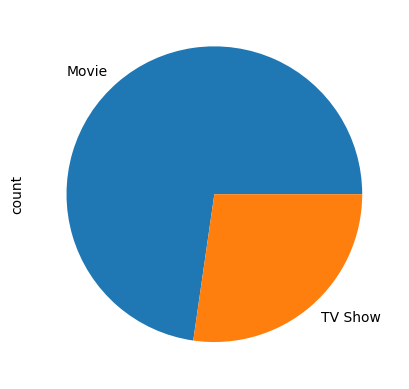

In [59]:
df_new["type"].value_counts().plot(kind="pie")

In [60]:
df_tvs.rename(columns={"duration":"seasons"},inplace=True)
df_tvs.head()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\241069733.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs.rename(columns={"duration":"seasons"},inplace=True)


,type,title,date_added,release_year,rating,seasons,description,day,month,year,month_name,weekday,country,director,cast,genre
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,International TV Shows
5,TV Show,Blood & Water,2021-09-24,2021,Adults,2,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,TV Dramas


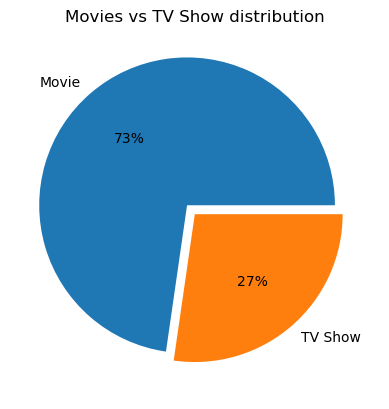

In [61]:
#labels =["movies","tv show"]
plt.pie(df_new["type"].value_counts(),labels=df_new["type"].value_counts().index,
       explode=(0.08,0),autopct="%0.0f%%")
plt.title("Movies vs TV Show distribution")
plt.show()

In [62]:
df_temp=df_new.drop_duplicates(subset=["country","title"])
df_temp

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,International TV Shows
58,TV Show,Ganglands,2021-09-24,2021,Adults,1 Season,To protect his family from a powerful drug lor...,24,9,2021,September,Friday,unknown,Julien Leclercq,Sami Bouajila,Crime TV Shows
85,TV Show,Kota Factory,2021-09-24,2021,Adults,2 Seasons,In a city of coaching centers known to train I...,24,9,2021,September,Friday,India,unknown,Mayur More,International TV Shows
109,TV Show,Midnight Mass,2021-09-24,2021,Adults,1 Season,The arrival of a charismatic young priest brin...,24,9,2021,September,Friday,unknown,Mike Flanagan,Kate Siegel,TV Dramas
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
198300,Movie,Zinzana,2016-03-09,2015,Adults,96 min,Recovering alcoholic Talal wakes up inside a s...,9,3,2016,March,Wednesday,Jordan,Majid Al Ansari,Ali Suliman,Dramas
198318,Movie,Zodiac,2019-11-20,2007,Adults,158 min,"A political cartoonist, a crime reporter and a...",20,11,2019,November,Wednesday,United States,David Fincher,Mark Ruffalo,Cult Movies
198348,Movie,Zombieland,2019-11-01,2009,Adults,88 min,Looking to survive in a world taken over by zo...,1,11,2019,November,Friday,United States,Ruben Fleischer,Jesse Eisenberg,Comedies
198362,Movie,Zoom,2020-01-11,2006,Kids,88 min,"Dragged from civilian life, a former superhero...",11,1,2020,January,Saturday,United States,Peter Hewitt,Tim Allen,Children & Family Movies


In [63]:
df_temp["country"].value_counts()

country
United States     3596
India             1038
United Kingdom     772
unknown            730
Canada             427
                  ... 
Sudan                1
Panama               1
Uganda               1
East Germany         1
Montenegro           1
Name: count, Length: 128, dtype: int64

In [64]:
x=df_temp["country"].value_counts().head(10)
x

country
United States     3596
India             1038
United Kingdom     772
unknown            730
Canada             427
France             383
Japan              313
Spain              228
Germany            223
South Korea        222
Name: count, dtype: int64

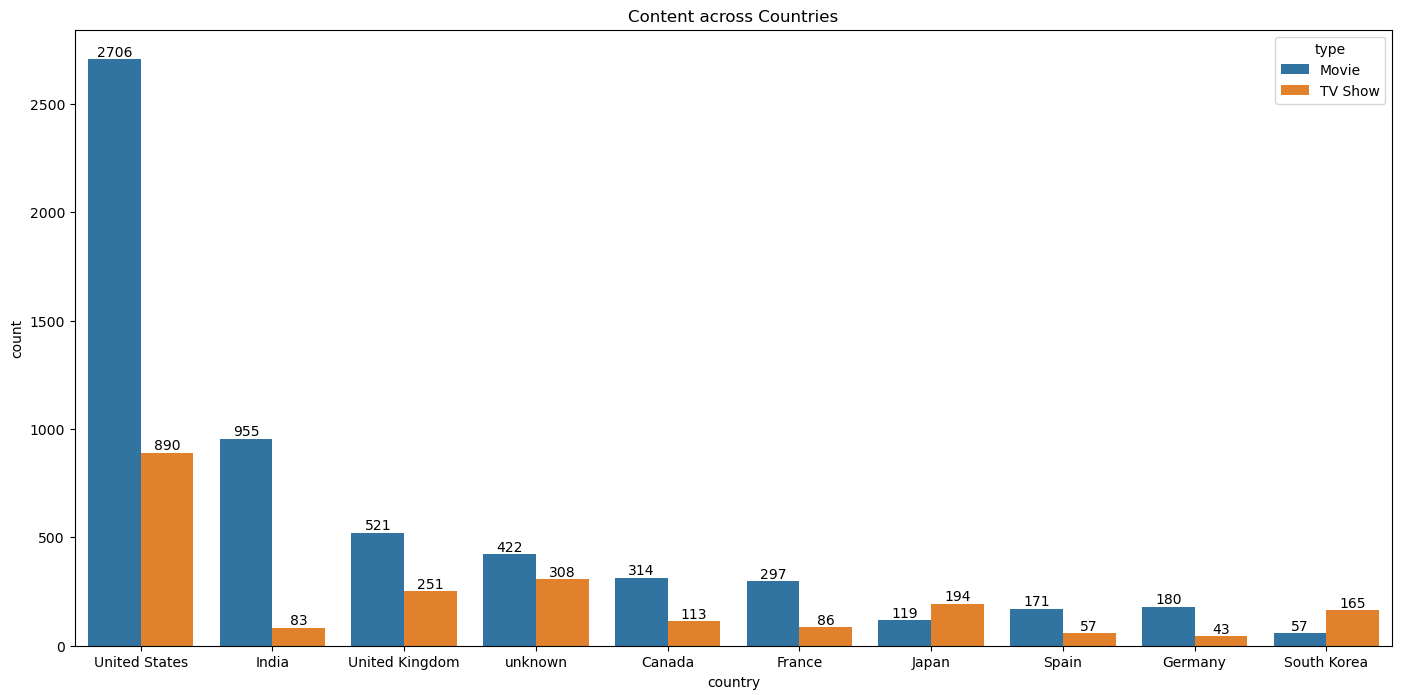

In [65]:
plt.figure(figsize=(17,8))
plt.title("Content across Countries")
label=sns.countplot(data=df_temp,x="country",hue="type",order=x.index)
for i in label.containers:
    label.bar_label(i)
plt.show()
#plt.savegif("2.jpg")

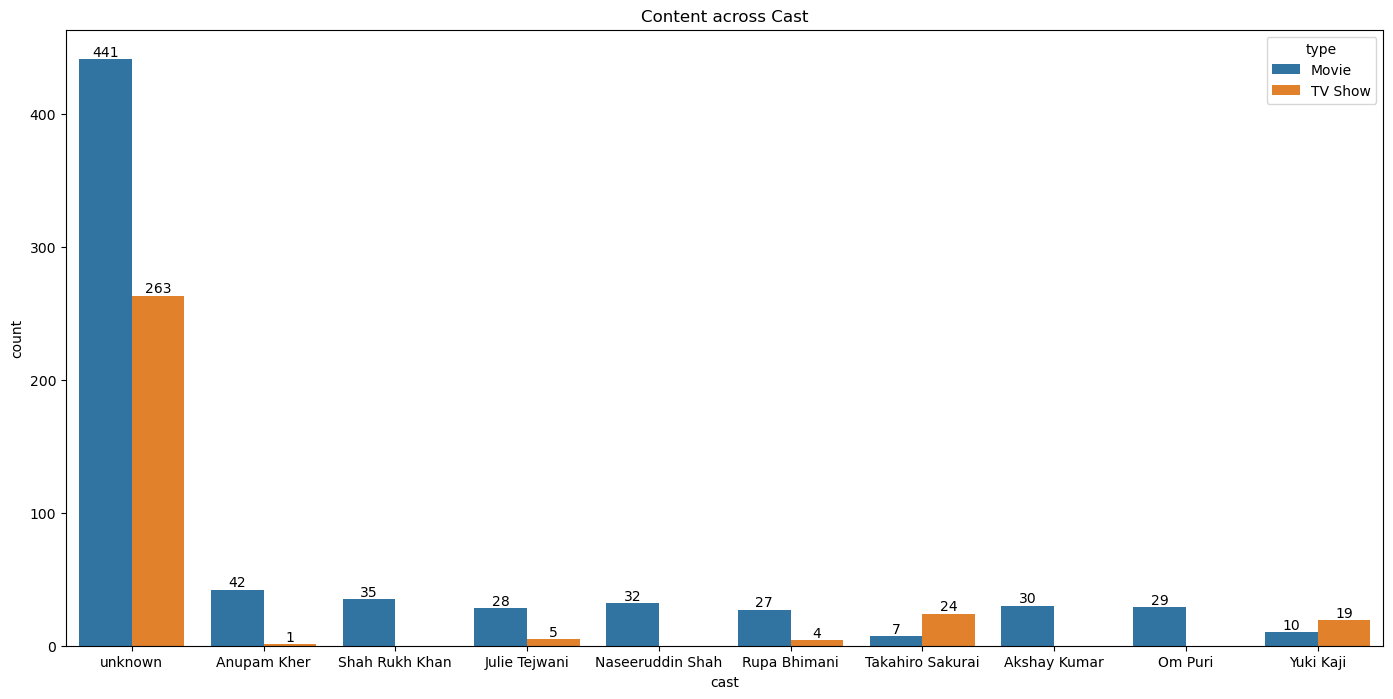

In [66]:
df_temp=df_new.drop_duplicates(subset=["cast","title"])
x=df_temp["cast"].value_counts().head(10)
plt.figure(figsize=(17,8))
plt.title("Content across Cast")
label=sns.countplot(data=df_temp,x="cast",hue="type",order=x.index)
for i in label.containers:
    label.bar_label(i)
plt.show()
#plt.savegif("2.jpg")

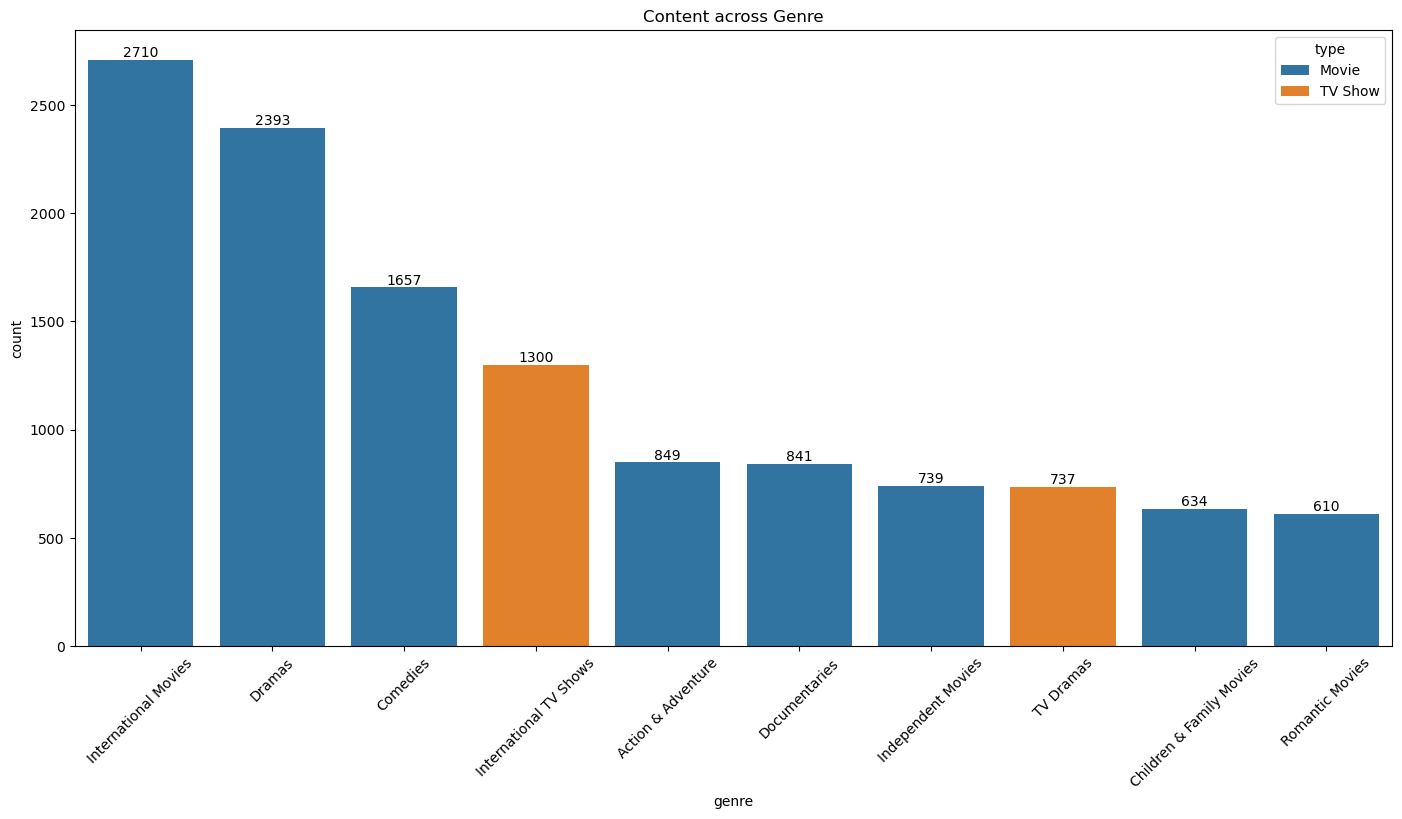

In [67]:
df_temp=df_new.drop_duplicates(subset=["genre","title"])
x=df_temp["genre"].value_counts().head(10)
plt.figure(figsize=(17,8))
plt.title("Content across Genre")
label=sns.countplot(data=df_temp,x="genre",hue="type",order=x.index)
plt.xticks(rotation=45)
for i in label.containers:
    label.bar_label(i)
plt.show()
#plt.savegif("2.jpg")

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\3738201799.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="director",order=df_movies_temp["director"].value_counts()[1:11].index,palette="husl")
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\3738201799.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="director",order=df_tvs_temp["director"].value_counts()[1:11].index,palette="husl")


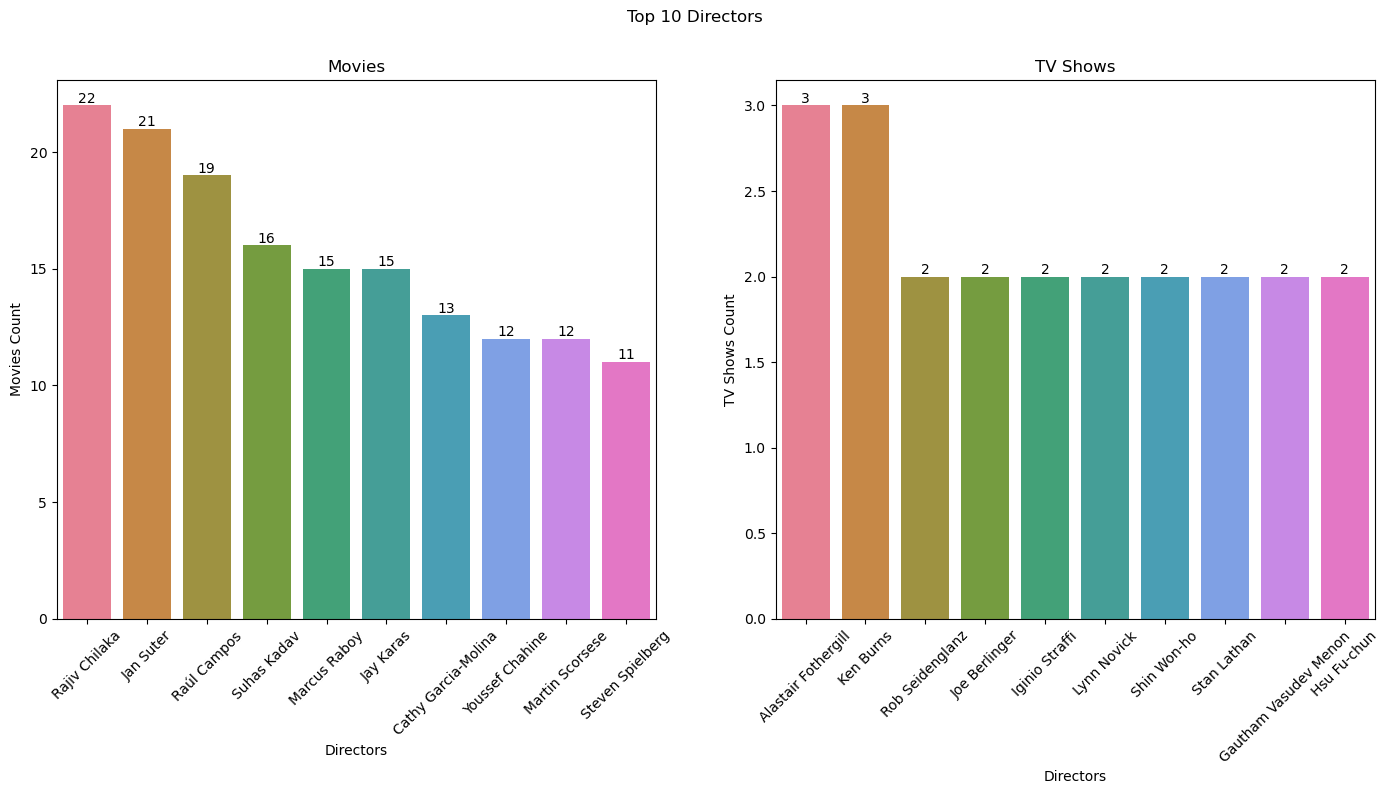

In [68]:
df_movies_temp=df_movies.drop_duplicates(subset=["director","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["director","title"])

plt.figure(figsize=(17,7))
plt.suptitle("Top 10 Directors")

plt.subplot(1,2,1)
label=sns.countplot(data=df_movies_temp,x="director",order=df_movies_temp["director"].value_counts()[1:11].index,palette="husl")

for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("Movies Count")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp,x="director",order=df_tvs_temp["director"].value_counts()[1:11].index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("TV Shows Count")
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\3832100617.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp, x="director", order=df_movies_temp["director"].value_counts()[1:11].index, palette="husl")
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\3832100617.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp, x="director", order=df_tvs_temp["director"].value_counts()[1:11].index, palette="husl")


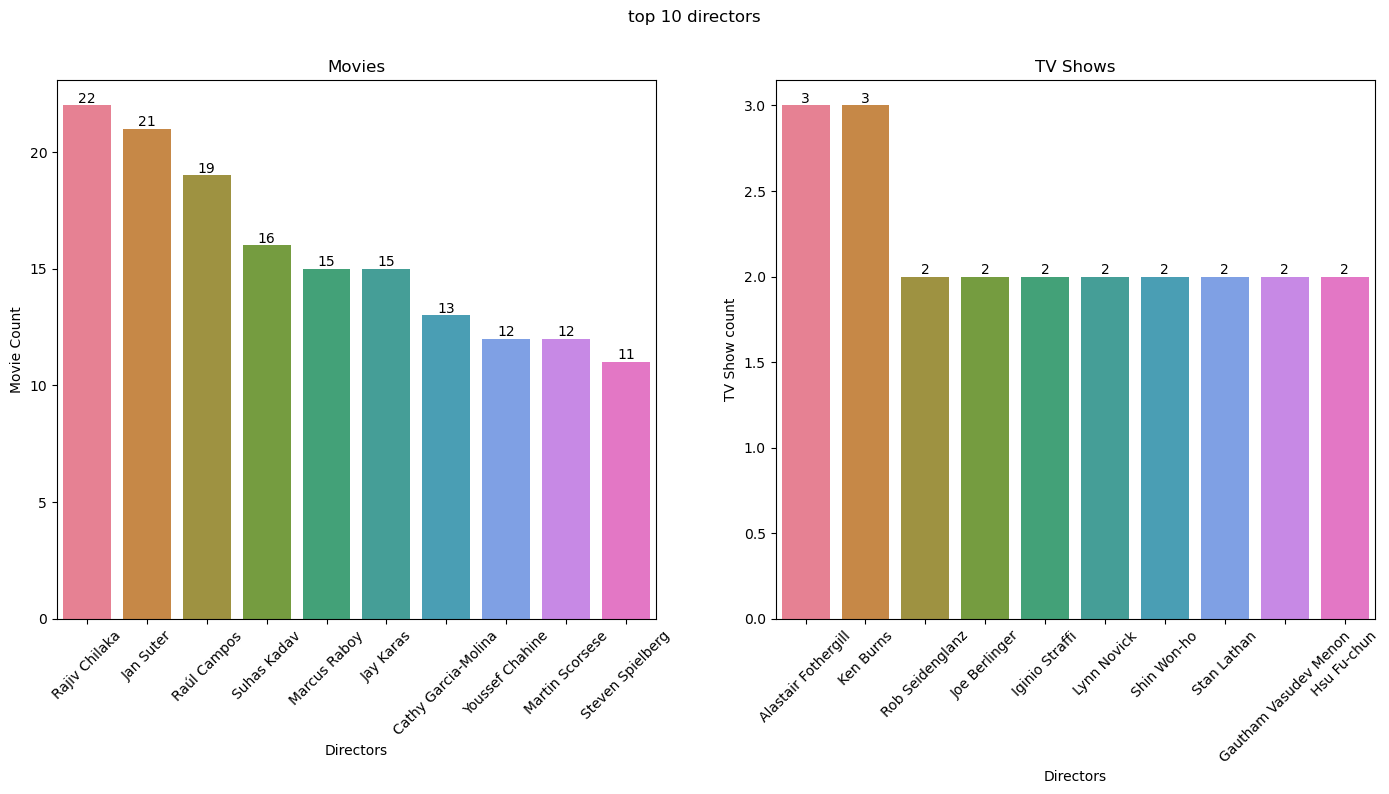

In [69]:
df_movies_temp=df_movies.drop_duplicates(subset=["director","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["director","title"])

plt.figure(figsize=(17,7))
plt.suptitle("top 10 directors")

plt.subplot(1,2,1)
label=sns.countplot(data=df_movies_temp, x="director", order=df_movies_temp["director"].value_counts()[1:11].index, palette="husl")

for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("Movie Count")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp, x="director", order=df_tvs_temp["director"].value_counts()[1:11].index, palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Directors")
plt.ylabel("TV Show count")

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\417634489.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp, x="genre", order=df_movies_temp["genre"].value_counts()[1:11].index, palette="husl")
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\417634489.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp, x="genre", order=df_tvs_temp["genre"].value_counts()[1:11].index, palette="husl")


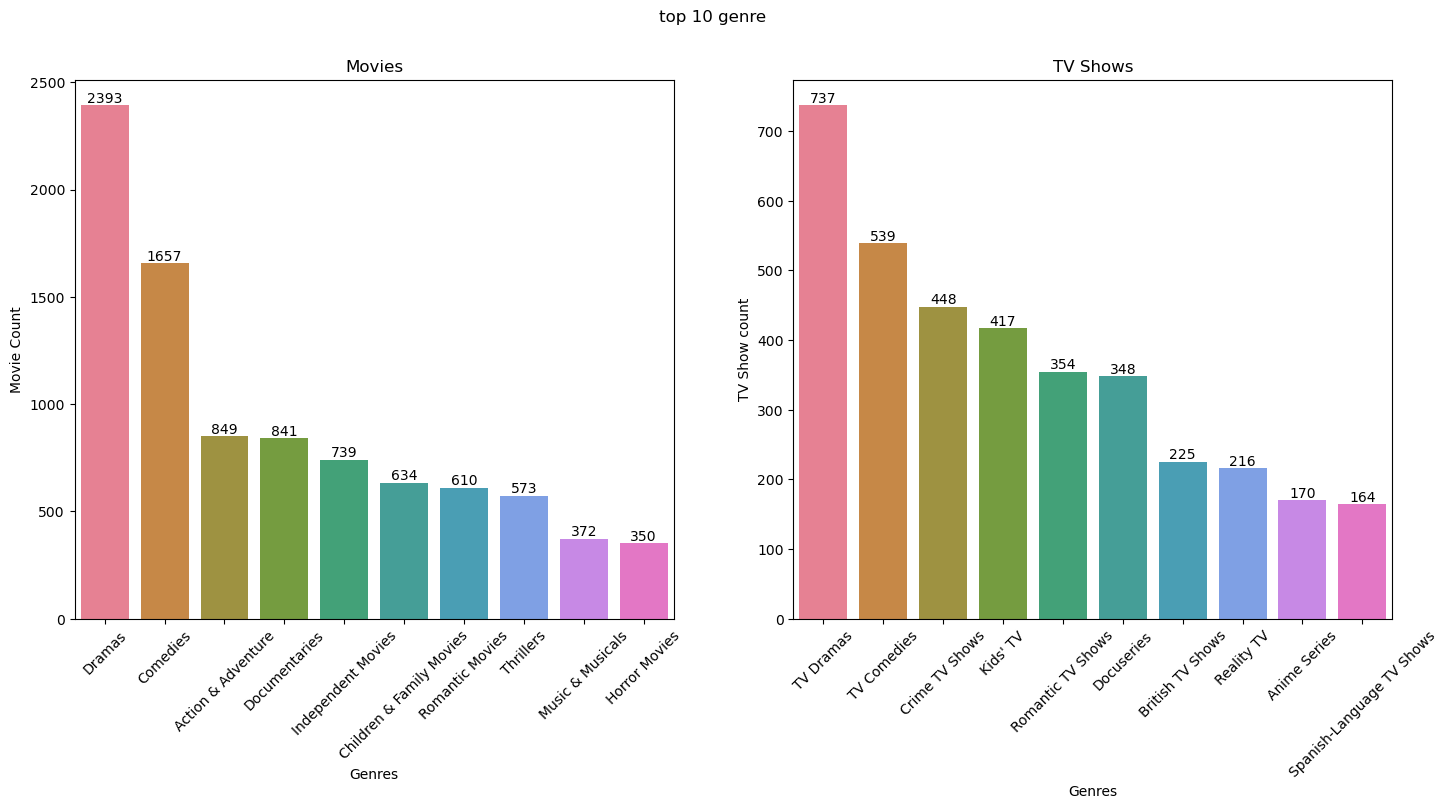

In [70]:
df_movies_temp=df_movies.drop_duplicates(subset=["genre","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["genre","title"])

plt.figure(figsize=(17,7))
plt.suptitle("top 10 genre")

plt.subplot(1,2,1)
label=sns.countplot(data=df_movies_temp, x="genre", order=df_movies_temp["genre"].value_counts()[1:11].index, palette="husl")

for i in label.containers:
    label.bar_label(i)
plt.title("Movies")
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("Movie Count")

plt.subplot(1,2,2)
label=sns.countplot(data=df_tvs_temp, x="genre", order=df_tvs_temp["genre"].value_counts()[1:11].index, palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.title("TV Shows")
plt.xticks(rotation=45)
plt.xlabel("Genres")
plt.ylabel("TV Show count")

plt.show()

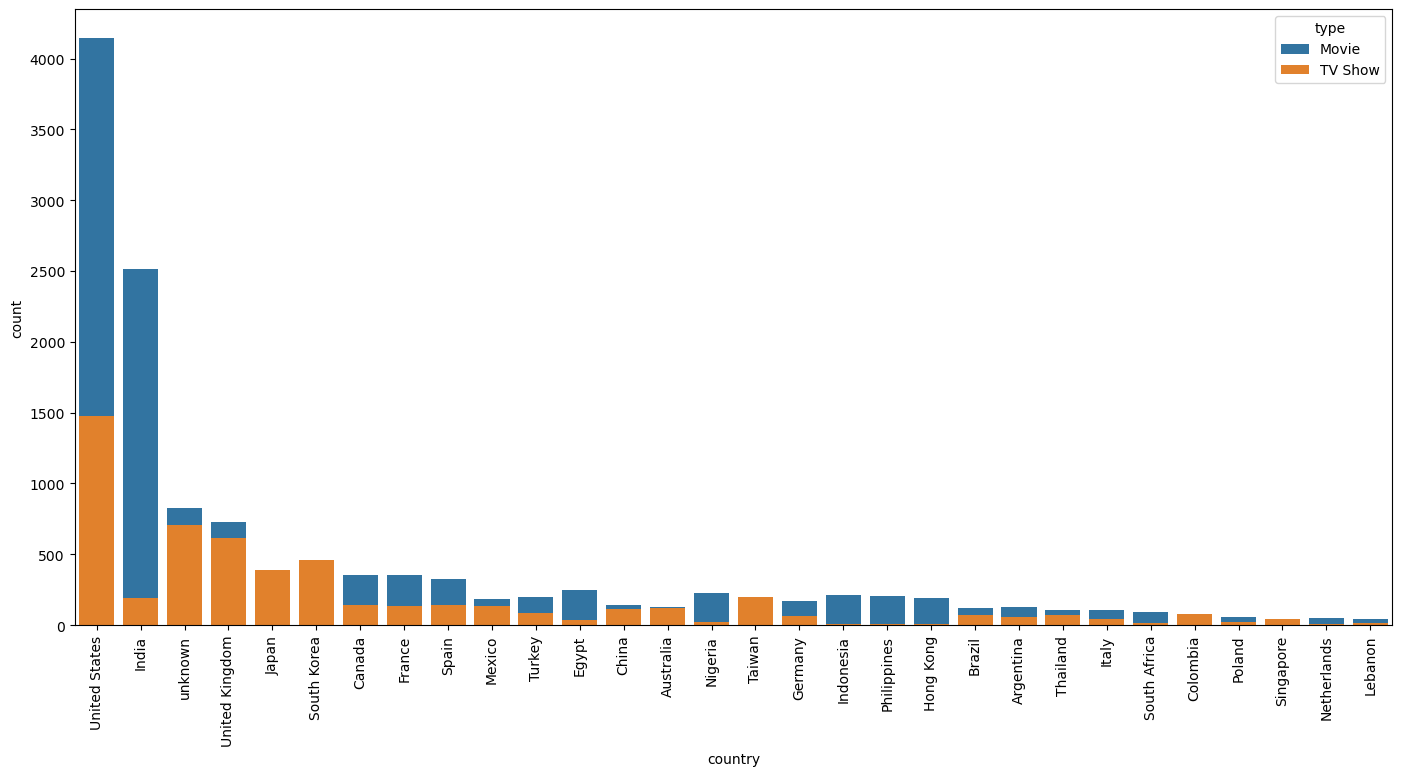

In [71]:
# stacked graph
df_temp=df_new.drop_duplicates(subset=["genre","title"])

plt.figure(figsize=(17,8))
plt.xticks(rotation=90)
sns.countplot(data=df_temp,x="country",hue="type",dodge=False,order=df_temp["country"].value_counts().head(30).index)
plt.show()

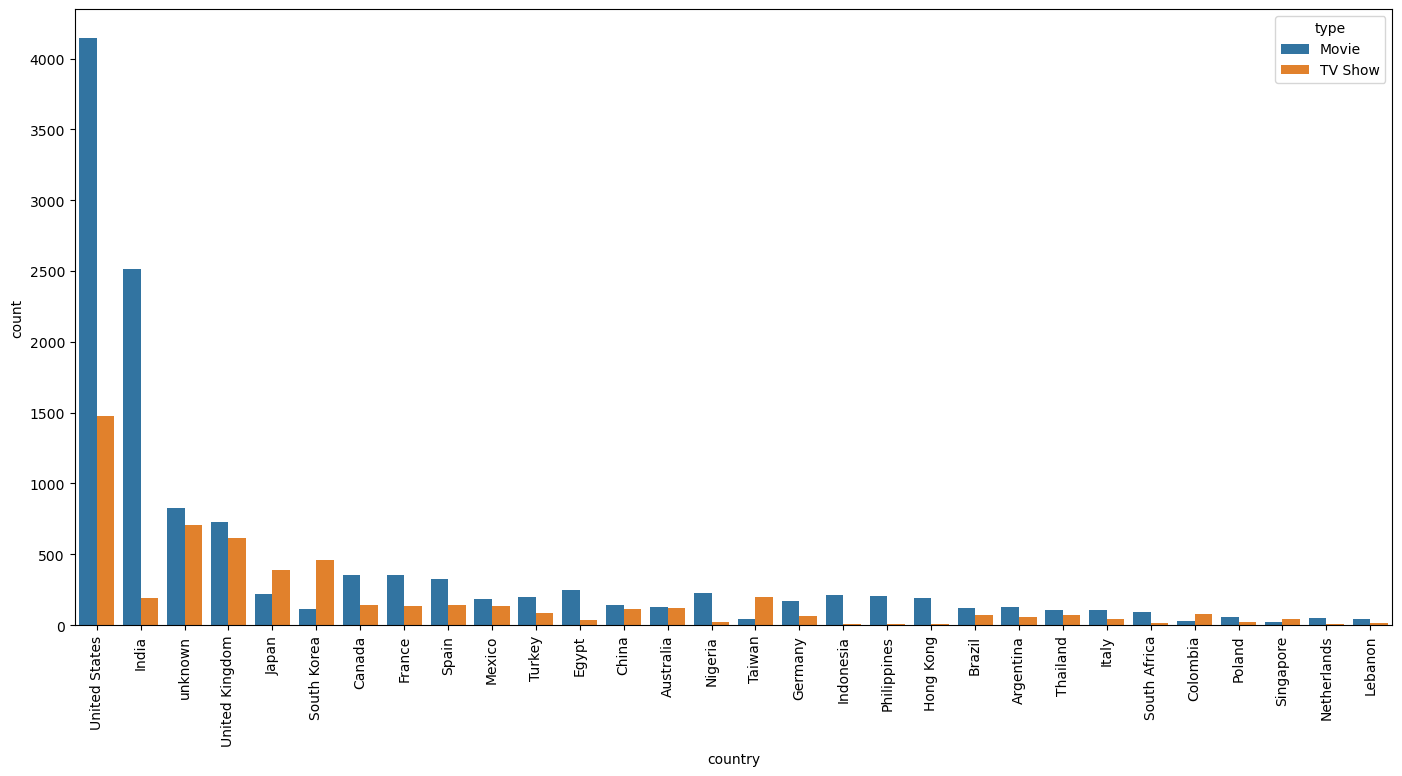

In [72]:
# stacked graph
df_temp=df_new.drop_duplicates(subset=["genre","title"])

plt.figure(figsize=(17,8))
plt.xticks(rotation=90)
sns.countplot(data=df_temp,x="country",hue="type",dodge=True,order=df_temp["country"].value_counts().head(30).index)
plt.show()

In [73]:
df_new.head()

,type,title,date_added,release_year,rating,duration,description,day,month,year,month_name,weekday,country,director,cast,genre
0,Movie,Dick Johnson Is Dead,2021-09-25,2020,Teens,90 min,"As her father nears the end of his life, filmm...",25,9,2021,September,Saturday,United States,Kirsten Johnson,unknown,Documentaries
1,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,International TV Shows
2,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Dramas
3,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Ama Qamata,TV Mysteries
4,TV Show,Blood & Water,2021-09-24,2021,Adults,2 Seasons,"After crossing paths at a party, a Cape Town t...",24,9,2021,September,Friday,South Africa,unknown,Khosi Ngema,International TV Shows


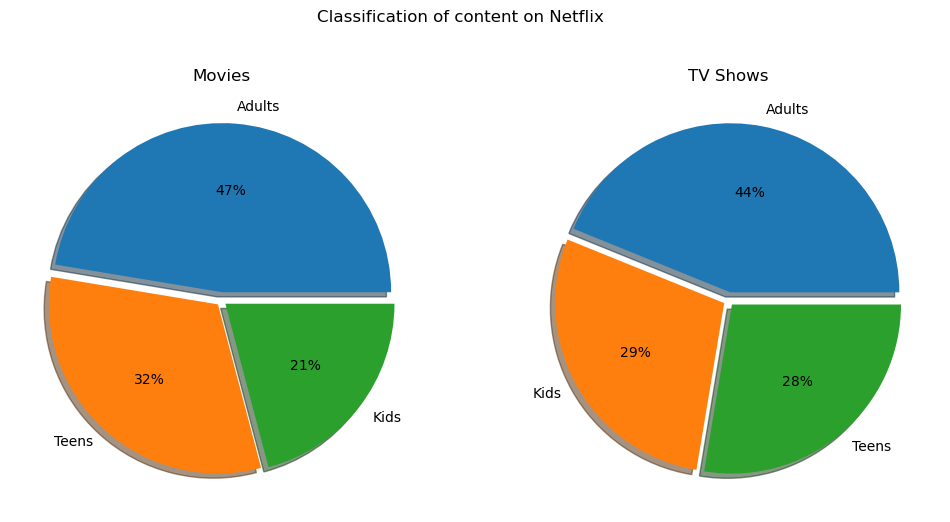

In [74]:
df_movies_temp=df_movies.drop_duplicates(subset=["rating","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["rating","title"])

plt.figure(figsize=(12,6))
plt.suptitle("Classification of content on Netflix")

plt.subplot(1,2,1)
plt.pie(df_movies_temp["rating"].value_counts(),labels=df_movies_temp["rating"].value_counts().index,autopct="%0.f%%",explode=(0.05,0.03,0.03),shadow=True)
plt.title("Movies")

plt.subplot(1,2,2)
plt.pie(df_tvs_temp["rating"].value_counts(),labels=df_tvs_temp["rating"].value_counts().index,autopct="%0.f%%",explode=(0.05,0.03,0.03),shadow=True)
plt.title("TV Shows")

plt.show()

In [75]:
df_movies_temp=df_movies.drop_duplicates(subset=["year","title"])

In [76]:
df_movies_temp["year"].value_counts()

year
2019    1412
2020    1281
2018    1223
2021     986
2017     813
2016     224
2015      51
2014      19
2011      13
2013       3
2012       3
2009       2
2008       1
Name: count, dtype: int64

In [77]:
mv_year=df_movies_temp["year"].value_counts()
mv_year.sort_index(inplace=True)

In [78]:
df_movies_temp["month_name"].value_counts()

month_name
July         559
April        542
October      535
December     535
January      535
March        518
August       515
September    510
November     489
June         485
May          433
February     375
Name: count, dtype: int64

In [79]:
month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]
mv_month=df_movies_temp["month_name"].value_counts().loc[month_order]

In [80]:
day_order=["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
mv_day=df_movies_temp["weekday"].value_counts().loc[day_order]

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\1491125825.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_movies_temp,x="month_name",order=mv_month.index,palette="husl")


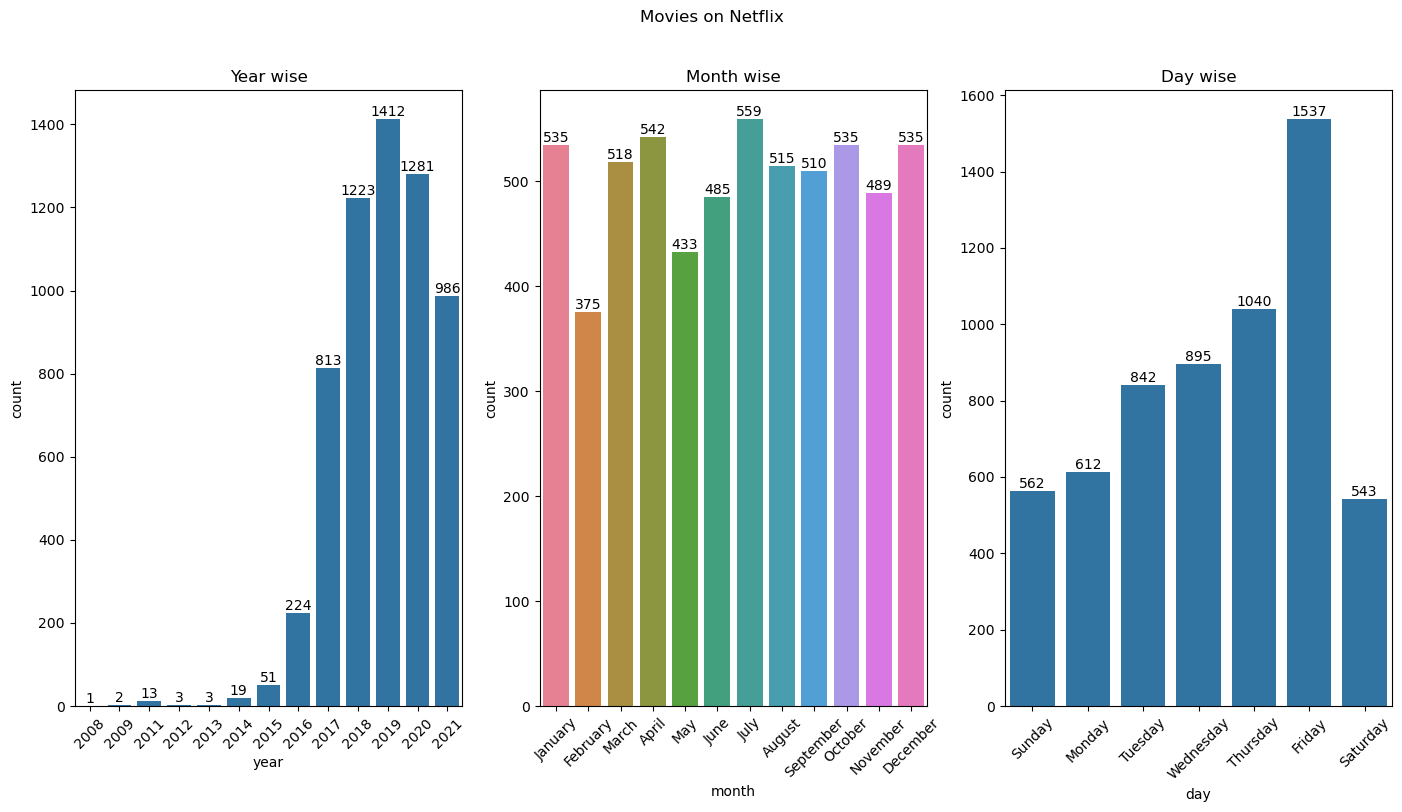

In [81]:
plt.figure(figsize=(17,8))
plt.suptitle("Movies on Netflix")

plt.subplot(1,3,1)
label=sns.countplot(data=df_movies_temp,x="year",order=mv_year.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("year")
plt.title("Year wise")

plt.subplot(1,3,2)
label=sns.countplot(data=df_movies_temp,x="month_name",order=mv_month.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("month")
plt.title("Month wise")

plt.subplot(1,3,3)
label=sns.countplot(data=df_movies_temp,x="weekday",order=mv_day.index)
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("day")
plt.title("Day wise")

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\626825007.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="year",order=mv_year.index,palette="husl")
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\626825007.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="month_name",order=mv_month.index,palette="viridis")
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\626825007.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  label=sns.countplot(data=df_tvs_temp,x="weekday",order=mv_day.index,palette="co

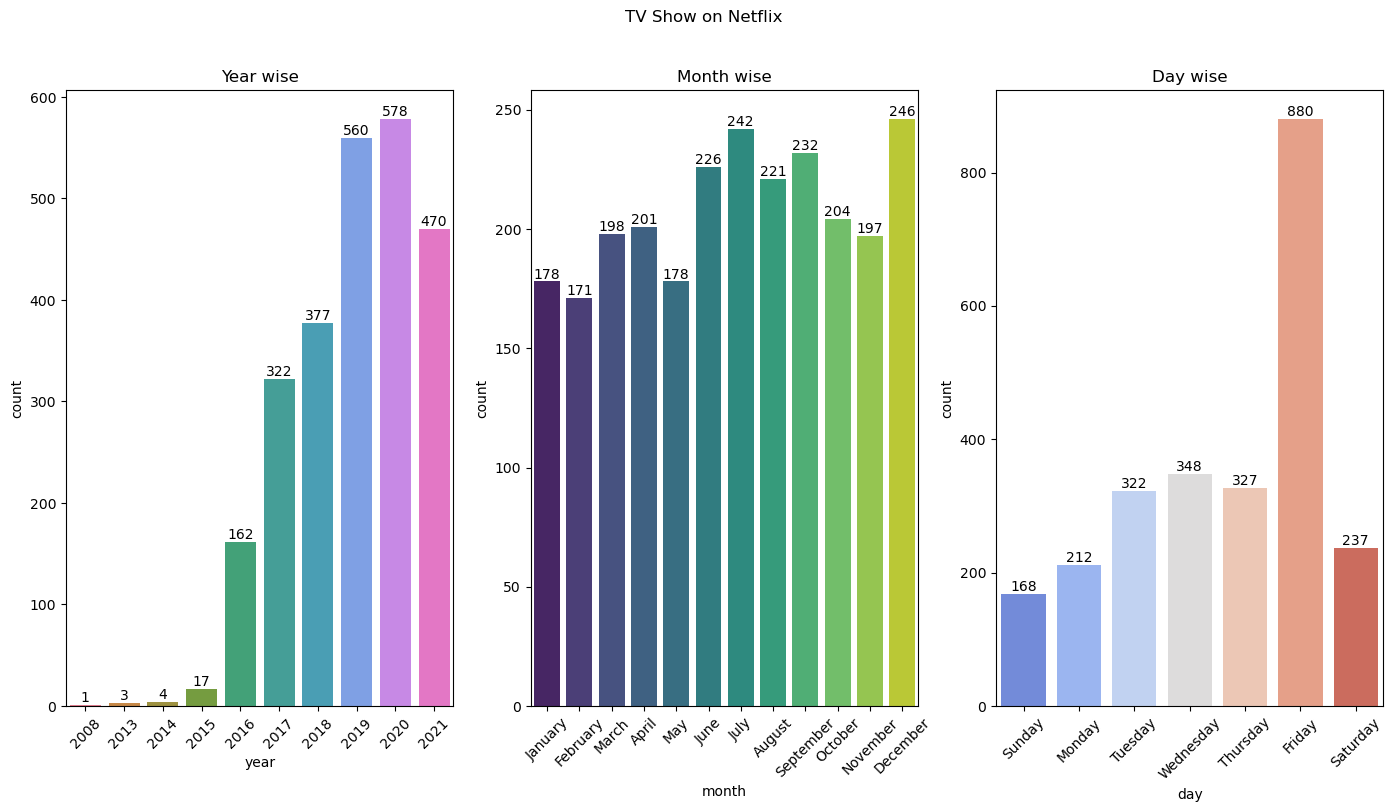

In [82]:
df_tvs_temp=df_tvs.drop_duplicates(subset=["year","title"])

mv_year=df_tvs_temp["year"].value_counts()
mv_year.sort_index(inplace=True)

month_order=["January","February","March","April","May","June","July","August","September","October","November","December"]
mv_month=df_tvs_temp["month_name"].value_counts().loc[month_order]

day_order=["Sunday","Monday","Tuesday","Wednesday","Thursday","Friday","Saturday"]
mv_day=df_tvs_temp["weekday"].value_counts().loc[day_order]

plt.figure(figsize=(17,8))
plt.suptitle("TV Show on Netflix")

plt.subplot(1,3,1)
label=sns.countplot(data=df_tvs_temp,x="year",order=mv_year.index,palette="husl")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("year")
plt.title("Year wise")

plt.subplot(1,3,2)
label=sns.countplot(data=df_tvs_temp,x="month_name",order=mv_month.index,palette="viridis")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("month")
plt.title("Month wise")

plt.subplot(1,3,3)
label=sns.countplot(data=df_tvs_temp,x="weekday",order=mv_day.index,palette="coolwarm")
for i in label.containers:
    label.bar_label(i)
plt.xticks(rotation=45)
plt.xlabel("day")
plt.title("Day wise")

plt.show()

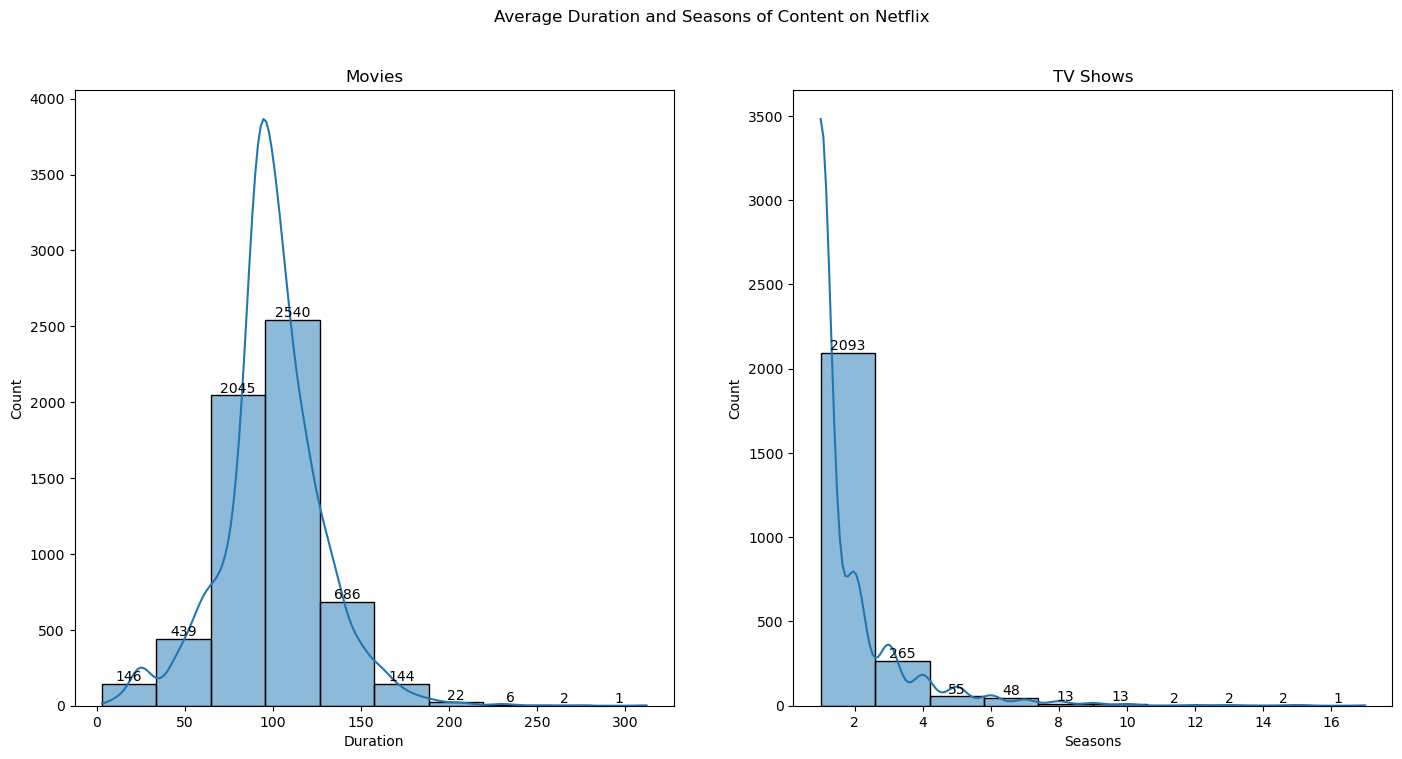

In [83]:
df_movies_temp=df_movies.drop_duplicates(subset=["duration","title"])
df_tvs_temp=df_tvs.drop_duplicates(subset=["seasons","title"])

plt.figure(figsize=(17,8))
plt.suptitle("Average Duration and Seasons of Content on Netflix")

plt.subplot(1,2,1)
label=sns.histplot(df_movies_temp["duration"].astype(int),bins=10,kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel("Duration")
plt.title("Movies")

plt.subplot(1,2,2)
label=sns.histplot(df_tvs_temp["seasons"].astype(int),bins=10,kde=True)
for i in label.containers:
    label.bar_label(i)
plt.xlabel("Seasons")
plt.title("TV Shows")

plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_22064\2540332864.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies_temp["duration"]=df_movies_temp["duration"].astype(int)
C:\Users\hp\AppData\Local\Temp\ipykernel_22064\2540332864.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_tvs_temp["seasons"]=df_tvs_temp["seasons"].astype(int)


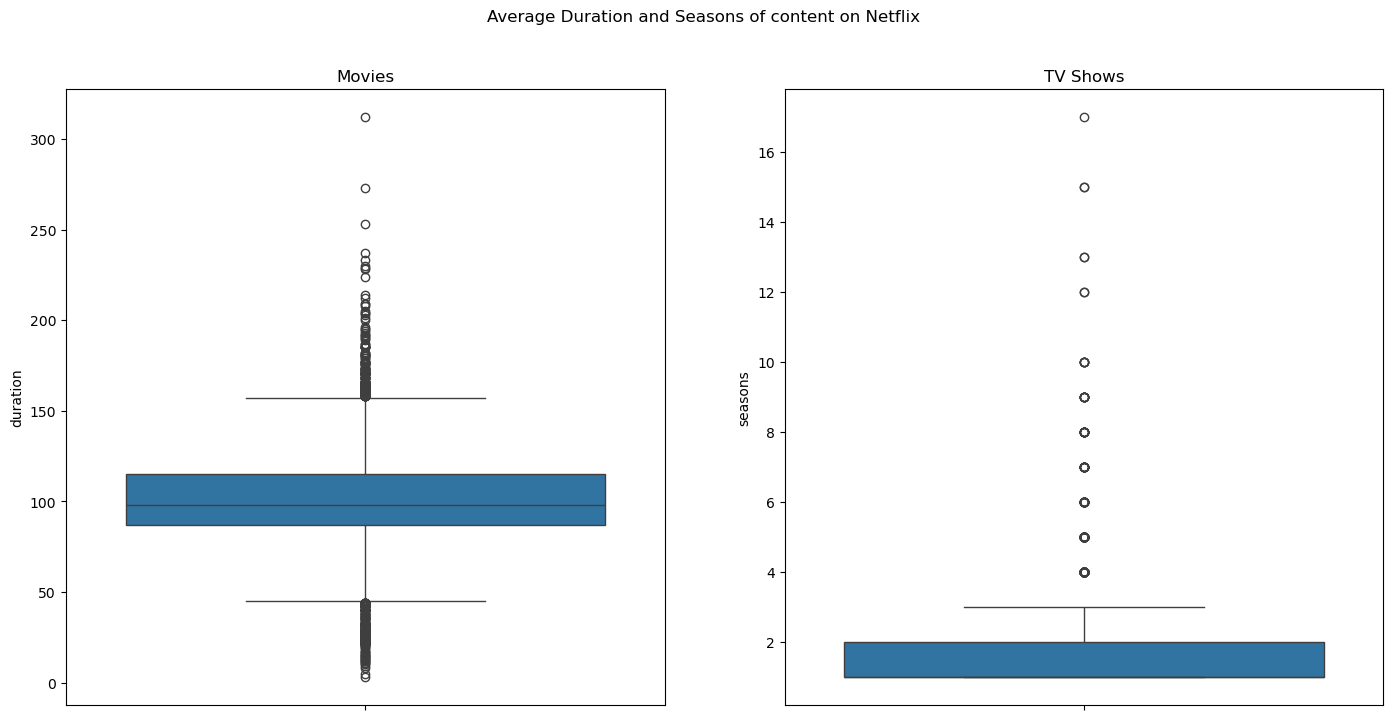

In [84]:
df_movies_temp["duration"]=df_movies_temp["duration"].astype(int)
df_tvs_temp["seasons"]=df_tvs_temp["seasons"].astype(int)

plt.figure(figsize=(17,8))
plt.suptitle("Average Duration and Seasons of content on Netflix")

plt.subplot(1,2,1)
sns.boxplot(y=df_movies_temp["duration"])
plt.title("Movies")

plt.subplot(1,2,2)
sns.boxplot(y=df_tvs_temp["seasons"])
plt.title("TV Shows")

plt.show()

In [85]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.


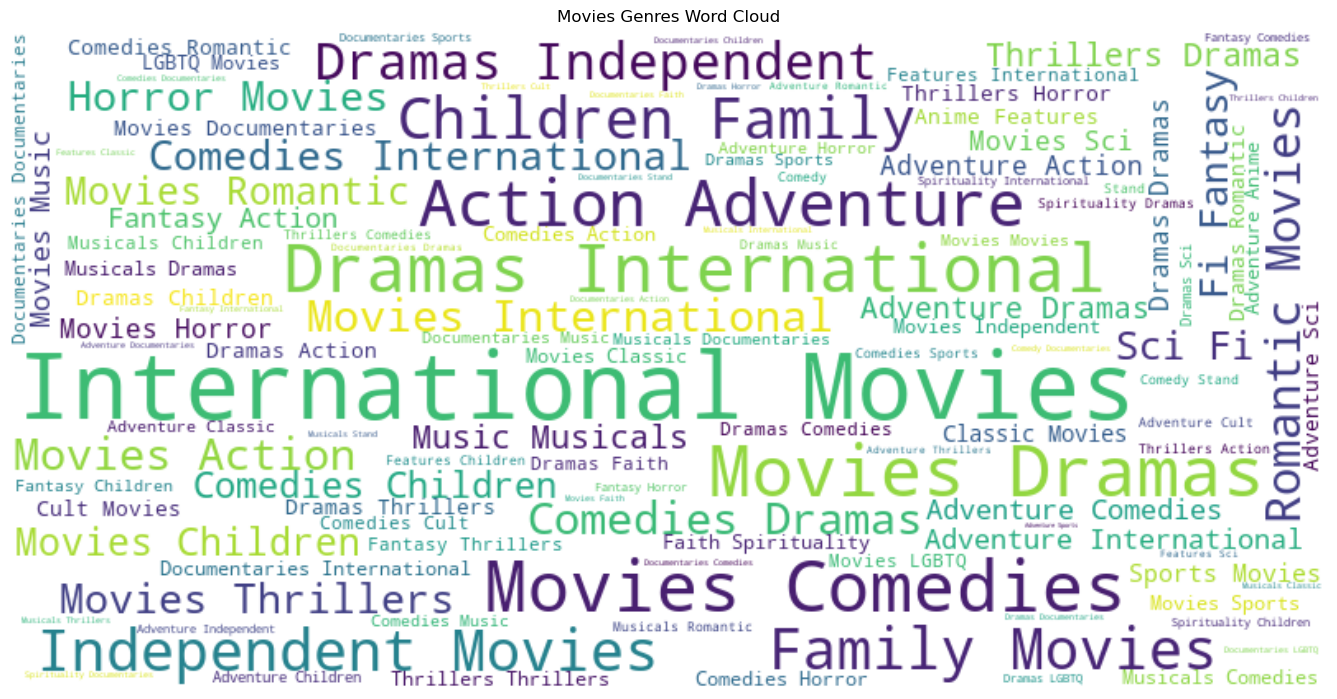

In [86]:
from wordcloud import WordCloud

genre_text=" ".join(df_movies["genre"])
wordcloud=WordCloud(width=800,height=400, background_color="white").generate(genre_text)

plt.figure(figsize=(17,10))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Movies Genres Word Cloud")
plt.show()

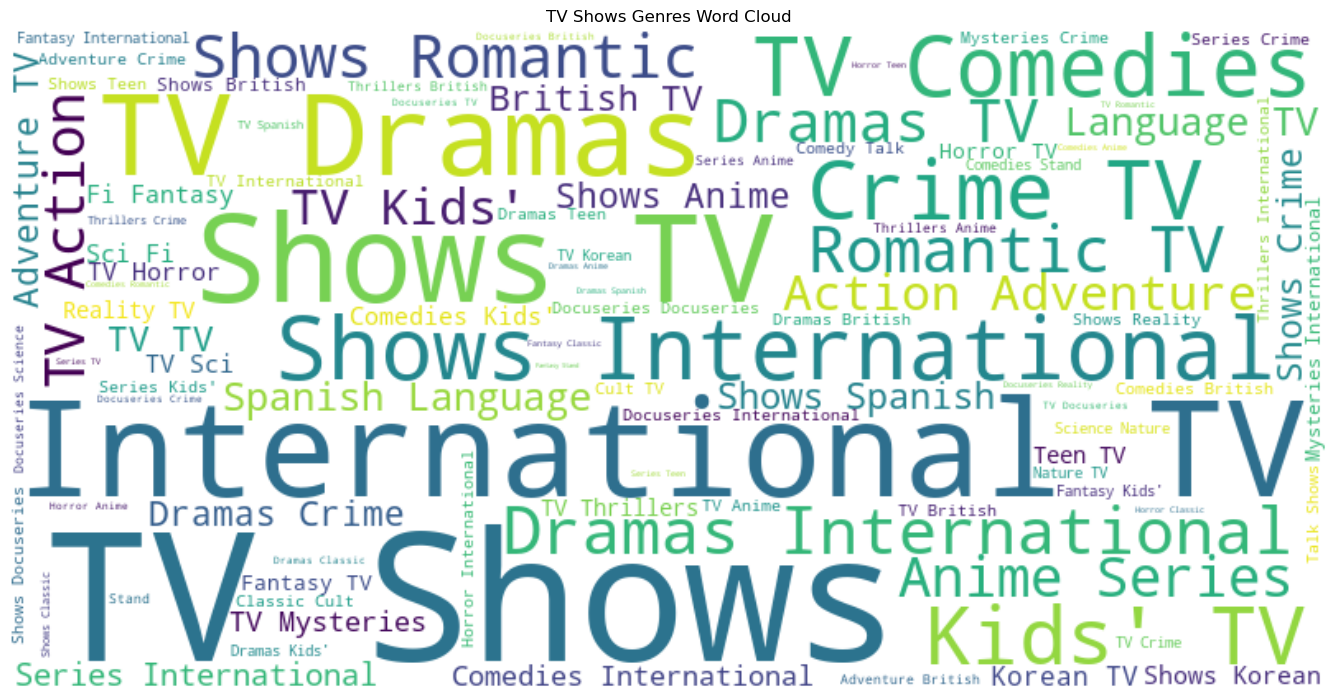

In [87]:
genre_text1=" ".join(df_tvs["genre"])
wordcloud=WordCloud(width=800,height=400, background_color="white").generate(genre_text1)

plt.figure(figsize=(17,10))

plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("TV Shows Genres Word Cloud")
plt.show()